In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lucidlenn/sloan-digital-sky-survey")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sloan-digital-sky-survey' dataset.
Path to dataset files: /kaggle/input/sloan-digital-sky-survey


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score ,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [6]:
import pandas as pd

file_path = '/kaggle/input/sloan-digital-sky-survey/Skyserver_SQL2_27_2018 6_51_39 PM.csv'

df = pd.read_csv(file_path)

df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [7]:
df.shape

(10000, 18)

In [8]:
df.isnull().sum()

,0
objid,0
ra,0
dec,0
u,0
g,0
r,0
i,0
z,0
run,0
rerun,0


In [9]:
print("Class balance:\n", df['class'].value_counts())

Class balance:
 class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64


The Data is Imbalanced

In [10]:
X = df.drop(['class', 'objid', 'specobjid'], axis=1)
y = df['class']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic *Regression*

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

Random *Forest*

In [13]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

*KNN*

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

*Evaluation Function*

In [15]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    return [name, accuracy, precision, recall, f1]

*Evaluate All Models*

Accuracy: 0.9775
Precision: 0.9777043443641722
Recall: 0.9775
F1-score: 0.9774683567677693


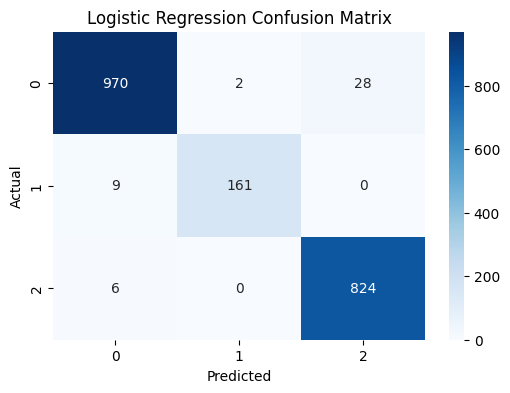

Accuracy: 0.9905
Precision: 0.9904698886534057
Recall: 0.9905
F1-score: 0.9904510801266311


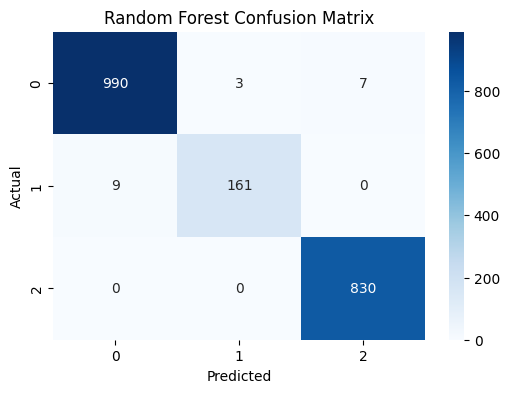

Accuracy: 0.896
Precision: 0.8980815064100516
Recall: 0.896
F1-score: 0.8957923995546657


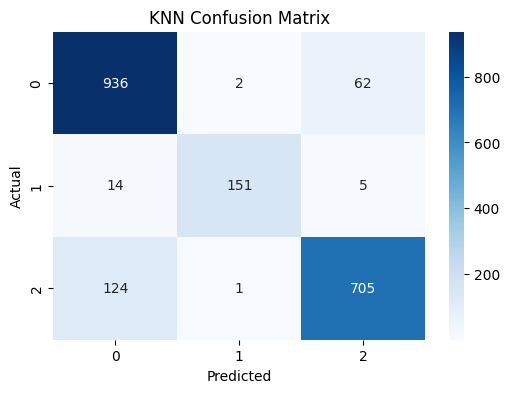

In [16]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        y_pred_log
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        y_pred_rf
    )
)

results.append(
    evaluate_model(
        'KNN',
        y_test,
        y_pred_knn
    )
)

*Summary Table*

In [17]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ]
)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.9775   0.977704  0.9775  0.977468
1        Random Forest    0.9905   0.990470  0.9905  0.990451
2                  KNN    0.8960   0.898082  0.8960  0.895792


*Choose Best Model*

Random Forest achieved the highest F1-score and accuracy compared to the other models. Therefore, it was selected as the best model because it provided the most balanced performance across all evaluation metrics.

In [18]:
best_model = results_df.sort_values(
    by='F1-score',
    ascending=False
)

print(best_model)

                 Model  Accuracy  Precision  Recall  F1-score
1        Random Forest    0.9905   0.990470  0.9905  0.990451
0  Logistic Regression    0.9775   0.977704  0.9775  0.977468
2                  KNN    0.8960   0.898082  0.8960  0.895792


***1.2 task***

In [19]:

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_classes = len(np.unique(y))


y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)



In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
num_classes = len(np.unique(y_train))

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

history = nn_model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8164 - loss: 0.5005 - val_accuracy: 0.8950 - val_loss: 0.2858
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9045 - loss: 0.2772 - val_accuracy: 0.9115 - val_loss: 0.2307
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9191 - loss: 0.2291 - val_accuracy: 0.9305 - val_loss: 0.1870
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9323 - loss: 0.1971 - val_accuracy: 0.9485 - val_loss: 0.1603
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9423 - loss: 0.1701 - val_accuracy: 0.9465 - val_loss: 0.1477
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9476 - loss: 0.1572 - val_accuracy: 0.9595 - val_loss: 0.1303
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9557 - loss: 0.1428 - val_accuracy: 0.9630 - val_loss: 0.1238
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9585 - loss: 0.1354 - val_accuracy: 0.9695 - val_

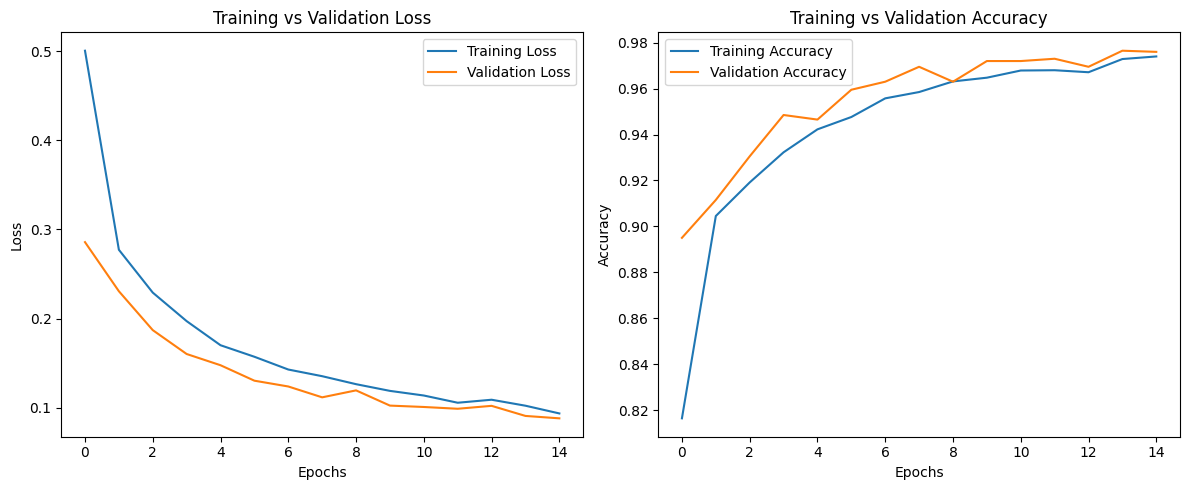

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
'''
Neural Network Evaluation

The Neural Network achieved strong performance after applying feature scaling and Dropout layers.
The training and validation accuracy curves remained very close, indicating good generalization and low overfitting. In addition, both loss curves decreased steadily during training, showing effective learning behavior.
'''

'\nNeural Network Evaluation\n\nThe Neural Network achieved strong performance after applying feature scaling and Dropout layers.\nThe training and validation accuracy curves remained very close, indicating good generalization and low overfitting. In addition, both loss curves decreased steadily during training, showing effective learning behavior.\n'

In [23]:
'''
Model Comparison
Random Forest achieved the best overall performance with the fewest classification errors.

Logistic Regression also produced highly accurate predictions, while KNN showed more misclassifications compared to the other models.

Overall, the Neural Network achieved stable and accurate results after preprocessing and scaling the data.
'''

'\nModel Comparison\nRandom Forest achieved the best overall performance with the fewest classification errors.\n\nLogistic Regression also produced highly accurate predictions, while KNN showed more misclassifications compared to the other models.\n\nOverall, the Neural Network achieved stable and accurate results after preprocessing and scaling the data.\n'